In [1]:
include_barmer =  False

# we want to get the normalized expressions after batchcorrections
- we will not include the QC steps for now

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import pandas as pd
import scvi 
sc.settings.seed = 1
print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.3.3


In [3]:
dataloc = "/root/capsule/scratch/snRNAseq_LCNE_with_chrom.h5ad"
adata_sc_orig = sc.read_h5ad(dataloc)
adata_sc_orig.obs['actualsex'].value_counts()

actualsex
M    2577
F    2291
Name: count, dtype: int64

## removing  XY genes (keeping the nan and mitochondria genes) 

In [4]:
mask_xy = adata_sc_orig.var["chromosome"].isin(["X",'Y'])
# mask_mt = adata_sc_orig.var["chromosome"].isin(["MT"])
# mask_nan_chrom = adata_sc_orig.var["chromosome"].isna()
# mask_xy_or_nan_or_mt = mask_xy | mask_nan_chrom | mask_mt
mask_xy_or_nan_or_mt = mask_xy 

print(adata_sc_orig.shape[1],'before removing genes')
adata_sc_orig = adata_sc_orig[:, ~mask_xy_or_nan_or_mt.fillna(False)].copy()
print(adata_sc_orig.shape[1],'after removing genes')

29617 before removing genes
28705 after removing genes


In [6]:
if include_barmer:
    barseq_datapath = '/root/capsule/data/LCNE_barseq_counts_updated.csv'
    df = pd.read_csv(barseq_datapath)
    barseq_genes = df.iloc[:,0].tolist()
    barseq_genes = list(set(barseq_genes).intersection(adata_sc_orig.var_names))

filename = '/root/capsule/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

var_names = adata_mer.var_names.intersection(adata_sc_orig.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
adata_sc_orig.raw = adata_sc_orig.copy()


### check mitocondria genes contents for each sample

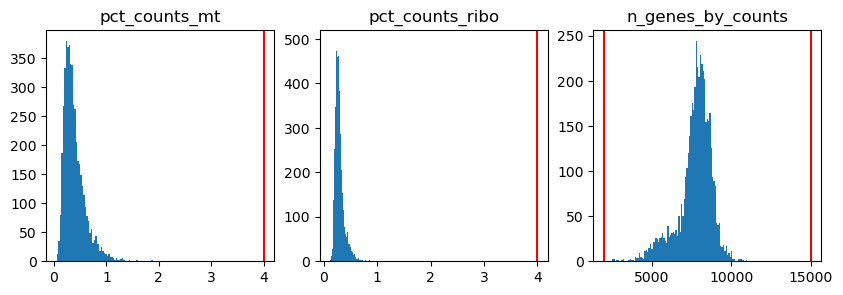

In [7]:
adata_sc_orig.var["mt"] = adata_sc_orig.var_names.str.startswith("mt-")
adata_sc_orig.var["ribo"] = adata_sc_orig.var_names.str.startswith(("Rps", "Rpl")) # no Mt
sc.pp.calculate_qc_metrics(adata_sc_orig, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True)
adata_sc_orig.obs['pct_counts_mt'].max()



mt_thre = 4
ribo_thre = 4
totalcounts_thre = (2000,15000)

plt.figure(figsize = (10,3))
plt.subplot(1,3,1);
plt.hist(adata_sc_orig.obs['pct_counts_mt'].values.flatten(), bins = 100);
plt.axvline(mt_thre, color = 'red')
plt.title('pct_counts_mt')

plt.subplot(1,3,2);
plt.hist(adata_sc_orig.obs['pct_counts_ribo'].values.flatten(), bins = 100);
plt.axvline(ribo_thre, color = 'red')
plt.title('pct_counts_ribo')

plt.subplot(1,3,3);
plt.hist(adata_sc_orig.obs['n_genes_by_counts'].values.flatten(), bins = 100);
plt.axvline(totalcounts_thre[0], color = 'red');
plt.axvline(totalcounts_thre[1], color = 'red')
plt.title('n_genes_by_counts');

In [8]:
adata_sc_orig.obs['percent.mt'].max()

np.float64(0.0)

# two ways to do the HVG
1. CPM with seurat v3 (normalized) - default 
2. log CPM with seurat 

In [9]:
sc.pp.highly_variable_genes(adata_sc_orig, n_top_genes=1500, 
                            flavor="seurat_v3",#batch_key="sex",
                            subset=False)
hvg_genes = sorted(
    set(
        adata_sc_orig.var_names[adata_sc_orig.var["highly_variable"]].tolist()
        + ["Dbh", "Th"]
    )
)

assert len(hvg_genes) == len(set(hvg_genes))
if include_barmer:
    genes_to_keep = sorted(list(set(hvg_genes) | set(adata_mer.var_names.tolist()) | set(barseq_genes)))
else:
    genes_to_keep = sorted(list(set(hvg_genes)))  # Also sort this one
print(len(genes_to_keep))  # 1769 or 1500 for now!

1502


In [10]:
'Shox2' in hvg_genes

True

In [11]:

genes_of_interest = ["Dbh", "Th", "Shox2", "Pdyn","Htr2a","Htr2b"]
in_hvg = [g for g in genes_of_interest if g in hvg_genes]
not_in_hvg = [g for g in genes_of_interest if g not in hvg_genes]
print("In HVG list:", in_hvg)
print("Missing from HVG list:", not_in_hvg)

In HVG list: ['Dbh', 'Th', 'Shox2', 'Htr2a']
Missing from HVG list: ['Pdyn', 'Htr2b']


In [12]:
len([a for a in list(genes_to_keep) if 'Gm' in a])

297

In [13]:
# save raw, and change the observations columns etc
raw_adata = adata_sc_orig.copy()
adata_sc = raw_adata[:, genes_to_keep].copy()
adata_sc.raw = raw_adata[adata_sc.obs_names, :].copy()
totalcounts = np.sum(adata_sc.X, -1)
adata_sc.obs['totalcounts']=totalcounts
def batch_flag(x):
    # 1 for concatenated long strings, 0 for simple M/F
    return 1 if ';' in x else 2
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['sex'].apply(batch_flag).astype('O')
adata_sc.X = adata_sc.X.tocsr() # do this for the faster scvi implementation!

In [34]:
raw_adata.shape

(4868, 28705)

In [35]:
adata_sc.shape

(4868, 1502)

In [16]:
adata_sc_orig.shape

(4868, 28705)

# run scvi for the integrations

In [36]:
np.mean(adata_sc.X, 0) 

matrix([[ 1.06758422,  1.3147083 ,  0.07826623, ...,  8.34695974,
         12.87880033,  5.72863599]], shape=(1, 1502))

In [18]:
scvi.settings.seed = 421
scvi.model.SCVI.setup_anndata(adata_sc, batch_key='sex')
model = scvi.model.SCVI(adata_sc, n_layers=1, n_latent=4, gene_likelihood="zinb")
model.train(max_epochs=400)#,early_stopping=True)#,early_stopping_patience=45)

Seed set to 421
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [19]:
SCVI_LATENT_KEY = "X_scVI"
adata_sc.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [20]:
np.mean(adata_sc.obsm[SCVI_LATENT_KEY], 0)  # seed 42 results (with barmer): -0.02546425, -0.04029592, -0.09200841,  0.02213329

# no barmer seed 4 array([-0.01065198, -0.03663757, -0.02210931, -0.08312064], dtype=float32)

array([-0.0251593 ,  0.0638762 , -0.13210689, -0.00124789], dtype=float32)

In [21]:
sc.pp.neighbors(adata_sc, use_rep=SCVI_LATENT_KEY, n_neighbors=15, random_state=1)
sc.tl.umap(adata_sc,random_state=210, min_dist=.5)  

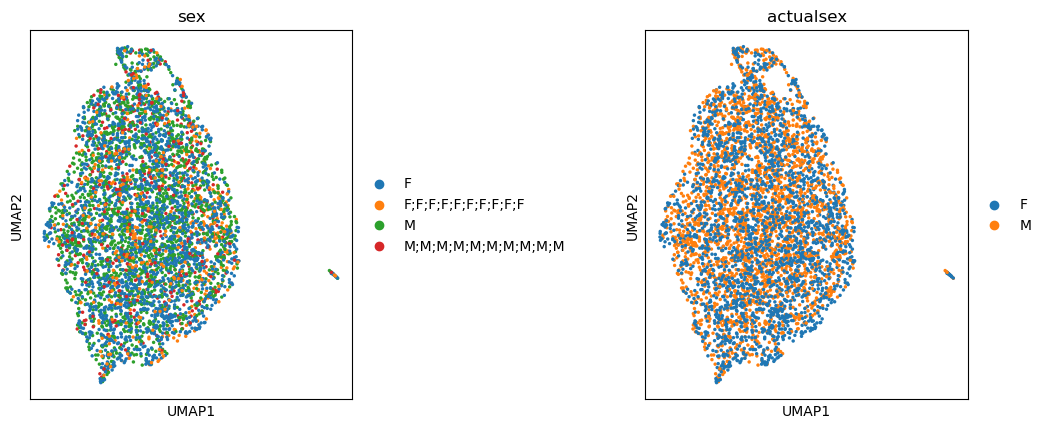

In [22]:
ax = sc.pl.umap(
    adata_sc,color=["sex",'actualsex'],
    ncols=3,show = False)
for a in ax:
    a.set_aspect('equal')

# investigate further on the small island 

It seems you use rank_genes_groups on the raw count data. Please logarithmize your data before calling rank_genes_groups.
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


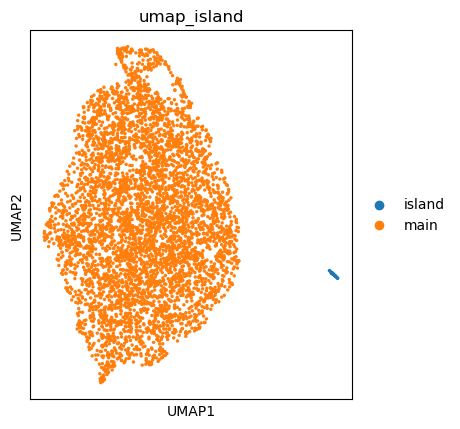

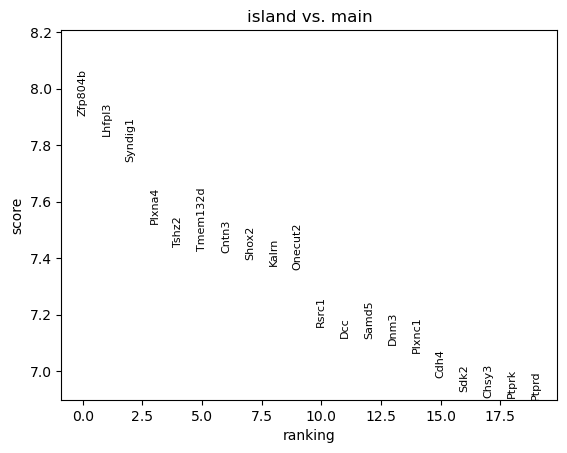

how many cells in the island?
23


In [23]:
from sklearn.cluster import KMeans
X = adata_sc.obsm["X_umap"]

# 1) many clusters on UMAP
kmeans = KMeans(n_clusters=50, random_state=0).fit(X)
labels = kmeans.labels_

# 2) smallest cluster = island
sizes = np.bincount(labels)
island_label = sizes.argmin()

adata_sc.obs["umap_island"] = pd.Categorical(
    np.where(labels == island_label, "island", "main")
)

# quick check
a=sc.pl.umap(adata_sc, color="umap_island", show = False)
a.set_aspect('equal')

# 3) DE: island vs main
sc.tl.rank_genes_groups(
    adata_sc,
    groupby="umap_island",
    groups=["island"],
    reference="main",
    method="wilcoxon",
)

sc.pl.rank_genes_groups(adata_sc, n_genes=20, sharey=False)

print('how many cells in the island?')
print((adata_sc.obs["umap_island"] == "island").sum())

### always confirm the island cells are the same cellss
todo: save this as a separate file and confirm eveyrtime

In [24]:
current_island = (
    adata_sc.obs
    .loc[adata_sc.obs["umap_island"] == "island"]
    .index.to_series(name="cell_id")
    .sort_values()
    .reset_index(drop=True)
)

# load saved reference
ref_island = pd.read_csv("/root/capsule/scratch/umap_island_cells_ref.csv")["cell_id"]
ref_island = ref_island.sort_values().reset_index(drop=True)

# exact match check (same cells, same counts)
same_cells = current_island.equals(ref_island)
print("Same island cells as reference:", same_cells)

Same island cells as reference: True


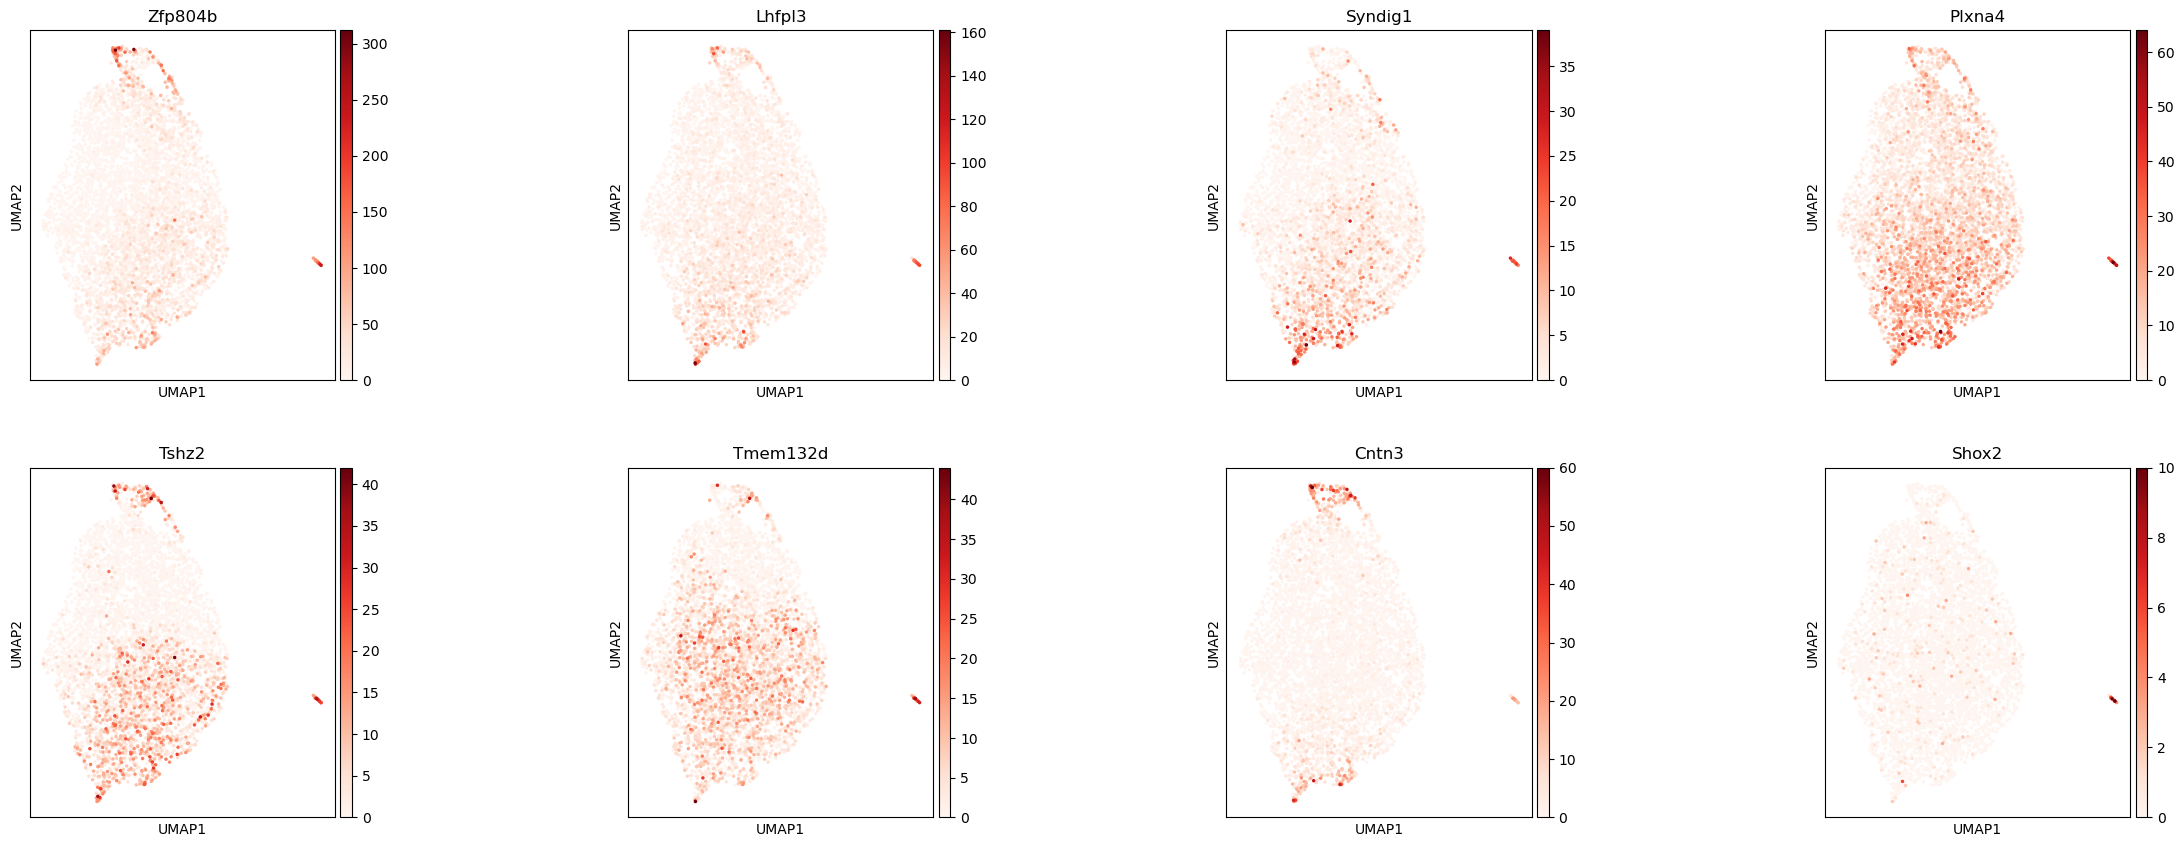

In [25]:
rg = adata_sc.uns["rank_genes_groups"]
topgene = pd.DataFrame({
    k: rg[k]["island"] for k in ["names", "scores", "pvals_adj"]
}).head(8)["names"].tolist()

ax = sc.pl.umap(
    adata_sc,
    color=topgene,sort_order=True,
    ncols=4,cmap = 'Reds', show = False
)
for a in ax: a.set_aspect('equal')

In [26]:
gene = "Shox2"
if adata_sc.raw is not None and gene in adata_sc.raw.var_names:
    expr = adata_sc.raw[:, gene].X
else:
    expr = adata_sc[:, gene].X
expr = np.asarray(expr.todense()).ravel()
ds   = adata_sc.obs["doublet_score"].values


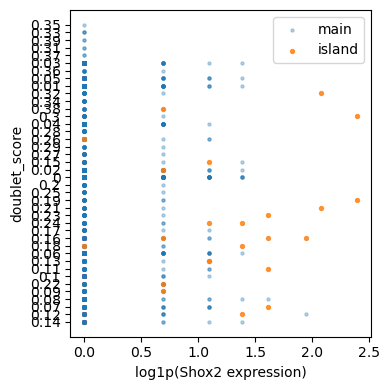

In [27]:
is_island = adata_sc.obs["umap_island"] == "island"

plt.figure(figsize=(4, 4))
plt.scatter(np.log1p(expr[~is_island]), ds[~is_island], s=5, alpha=0.3, label="main")
plt.scatter(np.log1p(expr[is_island]),  ds[is_island],  s=8, alpha=0.8, label="island")
plt.xlabel("log1p(Shox2 expression)")
plt.ylabel("doublet_score")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
ds[~is_island].astype(float).mean()

np.float64(0.07042724458204334)

In [29]:
ds[is_island].astype(float).mean()

np.float64(0.18478260869565222)

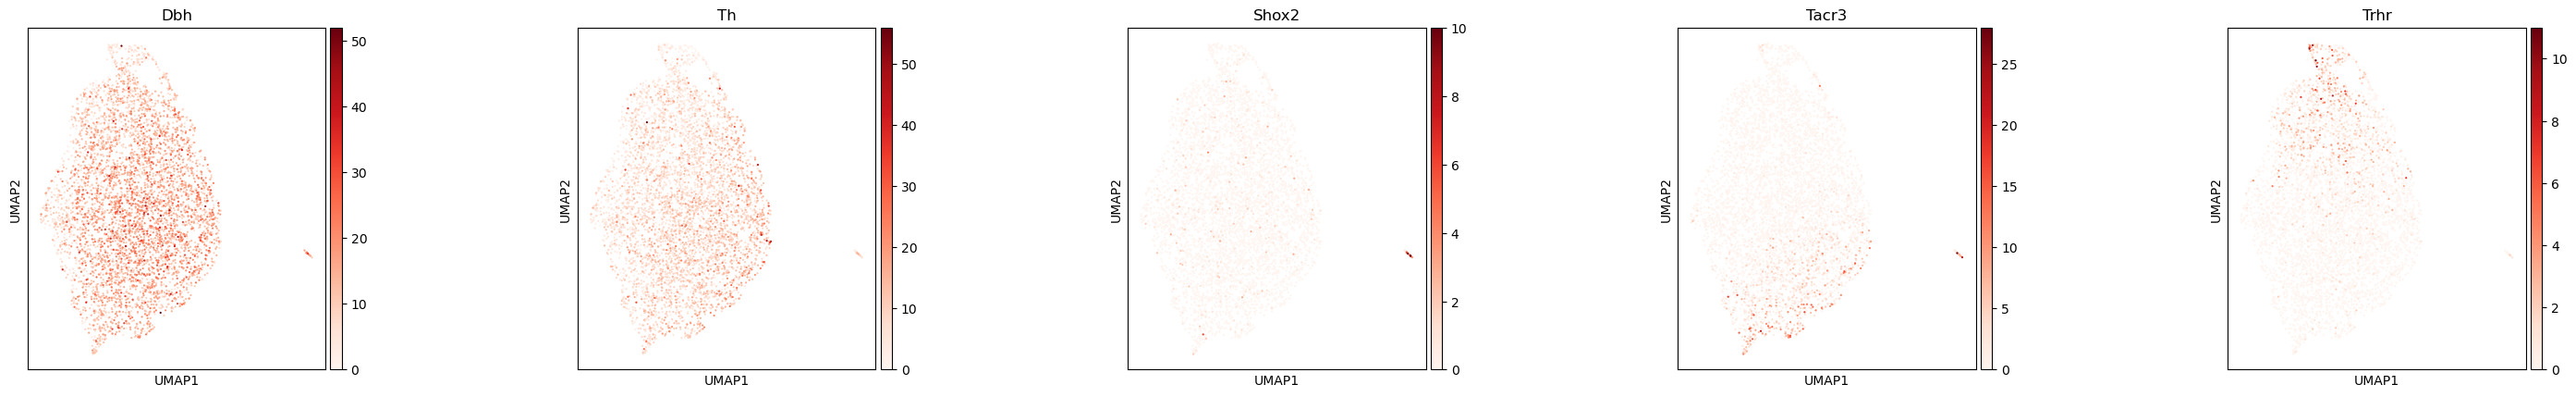

In [30]:

ax =sc.pl.umap(
    adata_sc,
    color=['Dbh','Th','Shox2','Tacr3','Trhr'],
    ncols=8,cmap = 'Reds', s = 10, show = False
)
for a in ax: a.set_aspect('equal')

In [31]:

num_cols = adata_sc.obs.select_dtypes(include="number").columns

summary = (adata_sc.obs.groupby("umap_island")[num_cols].median().T)

summary["delta"] = summary["island"] - summary["main"]
summary.sort_values("delta", ascending=False).head(15)


/tmp/ipykernel_5887/1578466316.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (adata_sc.obs.groupby("umap_island")[num_cols].median().T)


umap_island,island,main,delta
total_counts,53959.000000,49810.000000,4149.000000
nCount_RNA,55527.000000,51409.000000,4118.000000
totalcounts,5785.000000,4417.000000,1368.000000
n_genes_by_counts,8193.000000,7904.000000,289.000000
nFeature_RNA,8469.000000,8184.000000,285.000000
total_counts_ribo,142.000000,135.000000,7.000000
total_counts_mt,170.000000,164.000000,6.000000
pct_counts_mt,0.342570,0.337964,0.004607
percent.mt,0.000000,0.000000,0.000000
_scvi_labels,0.000000,0.000000,0.000000


In [32]:
from scipy.stats import ranksums

stats = []
for c in num_cols:
    x = adata_sc.obs.loc[adata_sc.obs.umap_island=="island", c]
    y = adata_sc.obs.loc[adata_sc.obs.umap_island=="main", c]
    if x.nunique() > 1 and y.nunique() > 1:
        stats.append((c, ranksums(x, y).pvalue))

pd.DataFrame(stats, columns=["col", "p"]).sort_values("p").head(15)

,col,p
8,totalcounts,0.000290
6,total_counts_ribo,0.062121
2,n_genes_by_counts,0.066812
1,nFeature_RNA,0.067178
9,_scvi_batch,0.217267
0,nCount_RNA,0.404237
3,total_counts,0.421977
4,total_counts_mt,0.663079
7,pct_counts_ribo,0.935875
5,pct_counts_mt,0.974552


In [33]:
adata_sc.obs.loc[
    adata_sc.obs["umap_island"] == "island",
    "doublet_score"].astype(float).values


array([0.18, 0.24, 0.22, 0.19, 0.38, 0.02, 0.16, 0.16, 0.09, 0.13, 0.15,
       0.07, 0.13, 0.3 , 0.21, 0.18, 0.12, 0.23, 0.11, 0.16, 0.26, 0.24,
       0.32])

# get the batch average normalized expression counts
- Denoised expression with batch “removed”

In [40]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print(all_batches)

['F', 'F;F;F;F;F;F;F;F;F;F', 'M', 'M;M;M;M;M;M;M;M;M;M']


In [41]:
X_hat_avg = model.get_normalized_expression(
    adata=adata_sc,
    transform_batch=all_batches,    
    library_size= 1, # we wont change this to 1e+6 here for now
    return_numpy=False
)  
import anndata
adata_sc_BN = anndata.AnnData(X_hat_avg.copy())
adata_sc_BN.obs = adata_sc.obs.copy()
adata_sc_BN.obsm = adata_sc.obsm.copy()
adata_sc_BN.var = adata_sc.var.copy()

# save 
- the normalized counts are saved as `BN` layer
- for now we keep library size 1


### discard the 23 small island cell. only keep the main island here. 



In [42]:
cpm_scl= 1
adata_sc.layers["BN"] = X_hat_avg*cpm_scl


filename = 'snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad' if include_barmer else 'snRNAseq_LCNE_BN_d4_1-5k.h5ad' 
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['experimental_batch_id'].astype(str)

adata_sc_final = adata_sc[adata_sc.obs["umap_island"] != "island"].copy()
adata_sc_final.write(f"/root/capsule/results/{filename}")

